# 📊 Customer Behavior Analysis

## Project Overview

This project analyzes customer shopping behavior to identify purchasing patterns, customer segments, product performance, and factors associated with customer spending.

The analysis combines Python-based data preparation and exploratory analysis with PostgreSQL/SQL and Power BI to create an end-to-end customer analytics workflow.

### Project Objectives

- Understand customer purchasing behavior
- Analyze customer demographics
- Identify high-performing product categories
- Examine purchasing frequency and previous purchases
- Analyze subscription behavior
- Explore discounts and promotional activity
- Generate actionable business insights

### Project Workflow

**Data Loading → Data Quality Assessment → Data Cleaning → Feature Engineering → Exploratory Data Analysis → PostgreSQL/SQL Analysis → Power BI Dashboard**

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- PostgreSQL
- SQL
- Power BI
- DAX

## 1. Import Libraries & Load Dataset

The customer shopping behavior dataset is loaded using Pandas. The initial step is to inspect the structure and contents of the dataset before performing data cleaning and transformation.

In [2]:
import pandas as pd

df = pd.read_csv('customer_shopping_behavior.csv')

## 2. Initial Dataset Exploration

The first few records are inspected to understand the structure of the dataset and the types of customer and transaction attributes available.

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


### 2.1 Dataset Structure

The dataset structure is examined to identify:

- Number of records and variables
- Data types
- Missing values
- Numerical and categorical columns

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

### 2.2 Descriptive Statistics

Descriptive statistics are used to understand the distribution of numerical variables such as age, purchase amount, review rating, and previous purchases.

In [5]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


## 3. Data Quality Assessment

Before performing analysis, the dataset is checked for missing values.

Missing values can affect statistical calculations and downstream analysis, so they are identified and handled before continuing.

In [6]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

### 3.1 Handling Missing Review Ratings

The `Review Rating` column contains missing values.

Instead of replacing missing ratings with a single overall statistic, missing values are filled using the median review rating within each product category.

This preserves category-level differences while reducing the influence of extreme values.

In [7]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

### 3.2 Verification

The missing-value check is repeated to verify that the `Review Rating` values have been successfully handled.

In [8]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

## 4. Data Cleaning & Standardization

Column names are standardized to lowercase and spaces are replaced with underscores to make them easier to reference in Python and SQL queries.

The purchase amount column is also renamed to a shorter and more convenient name.

In [9]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df = df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'})

### 4.1 Final Column Names

The transformed column names are reviewed to confirm that the standardization was applied correctly.

In [10]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

## 5. Feature Engineering

### 5.1 Customer Age Groups

Customers are divided into four age groups using age quartiles.

The `qcut` method creates four groups containing approximately equal numbers of observations. The resulting groups are labeled as Young Adult, Adult, Middle-aged, and Senior for analysis and visualization.

In [11]:
# create a new column age_group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

### 5.1.1 Age Group Verification

A sample of age values and their assigned age groups is displayed to verify the newly created feature.

In [12]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


### 5.2 Purchase Frequency Conversion

The original dataset stores purchasing frequency as categorical values such as Weekly, Fortnightly, Monthly, Quarterly, and Annually.

These categories are mapped to approximate numbers of days between purchases to create a numerical feature that can support further analysis.

In [13]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

### 5.2.1 Frequency Feature Verification

The original purchasing-frequency category and its corresponding numerical representation are displayed to verify the transformation.

In [14]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


### 5.3 Discount and Promotional Fields

The discount and promotional-code fields are inspected to determine whether they provide distinct information or represent the same underlying behavior.

In [15]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


The two fields are compared to determine whether their values are identical across all records.

In [16]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

### 5.4 Removing Redundant Information

The comparison above shows that `promo_code_used` contains the same information as `discount_applied`.

Therefore, the redundant column is removed to avoid duplicate information in subsequent analysis.

In [17]:
# Remove duplicate promotional field

df = df.drop('promo_code_used', axis=1)

In [18]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='str')

# 6. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand customer demographics, purchasing behavior, product performance, subscription behavior, and promotional patterns.

The analysis uses numerical summaries and visualizations to identify patterns that can support business decision-making.

## 6.1 Customer Demographics

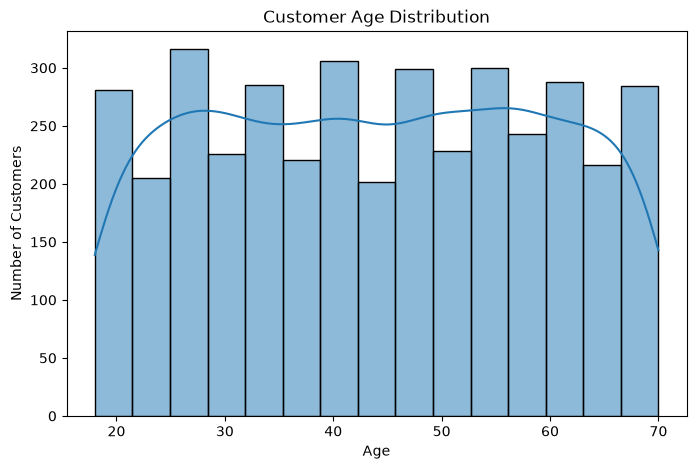

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=15, kde=True)
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

### Gender Distribution

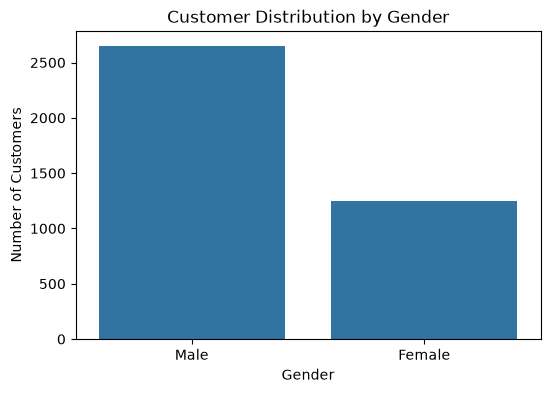

In [20]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender')
plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

## 6.2 Purchasing Behavior

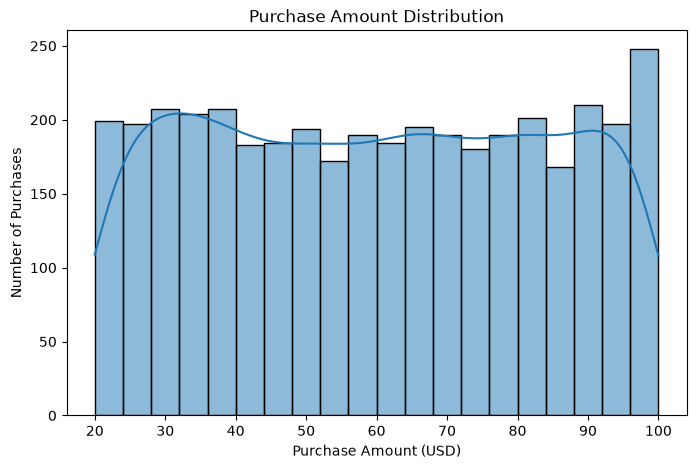

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(df['purchase_amount'], bins=20, kde=True)
plt.title('Purchase Amount Distribution')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Number of Purchases')
plt.show()

## 6.3 Product Category Analysis

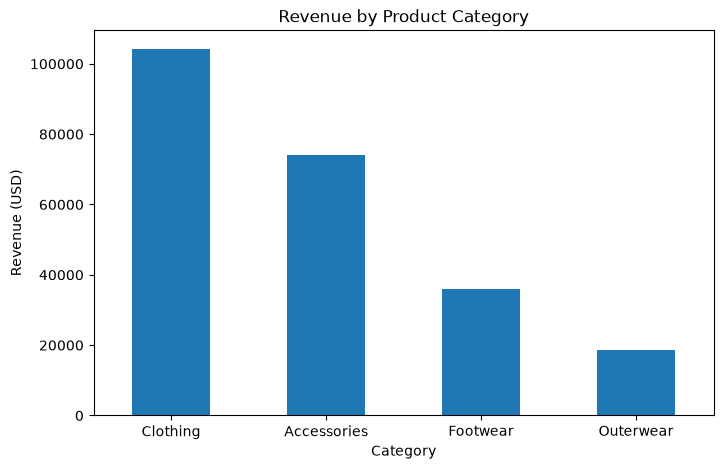

In [22]:
category_revenue = (
    df.groupby('category')['purchase_amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
category_revenue.plot(kind='bar')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=0)
plt.show()

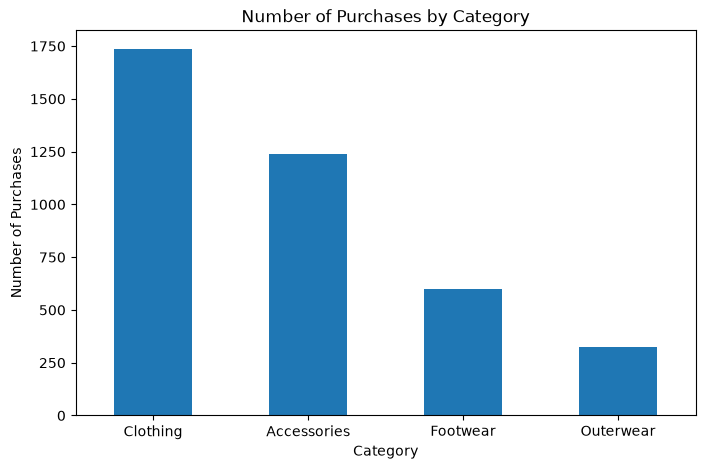

In [23]:
category_sales = (
    df['category']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar')
plt.title('Number of Purchases by Category')
plt.xlabel('Category')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=0)
plt.show()

## 6.4 Subscription Analysis

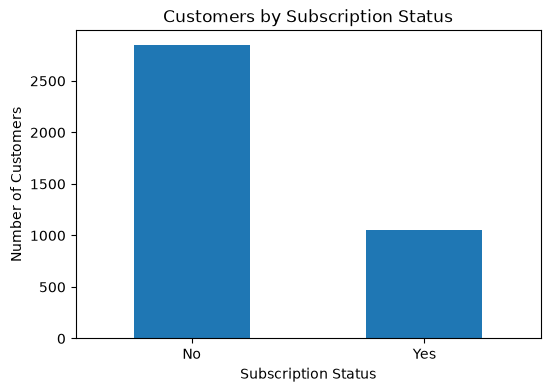

In [24]:
subscription_counts = df['subscription_status'].value_counts()

plt.figure(figsize=(6, 4))
subscription_counts.plot(kind='bar')
plt.title('Customers by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

## 6.5 Discount Analysis

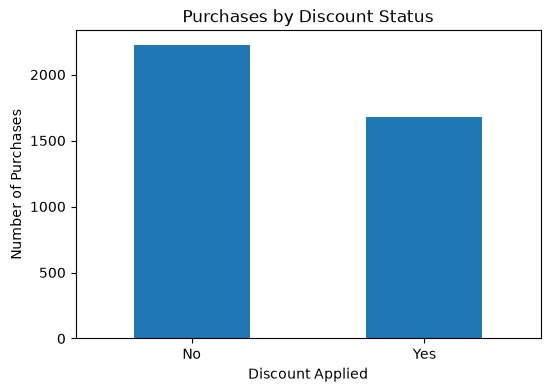

In [25]:
discount_counts = df['discount_applied'].value_counts()

plt.figure(figsize=(6, 4))
discount_counts.plot(kind='bar')
plt.title('Purchases by Discount Status')
plt.xlabel('Discount Applied')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=0)
plt.show()

## 6.6 Purchasing Frequency

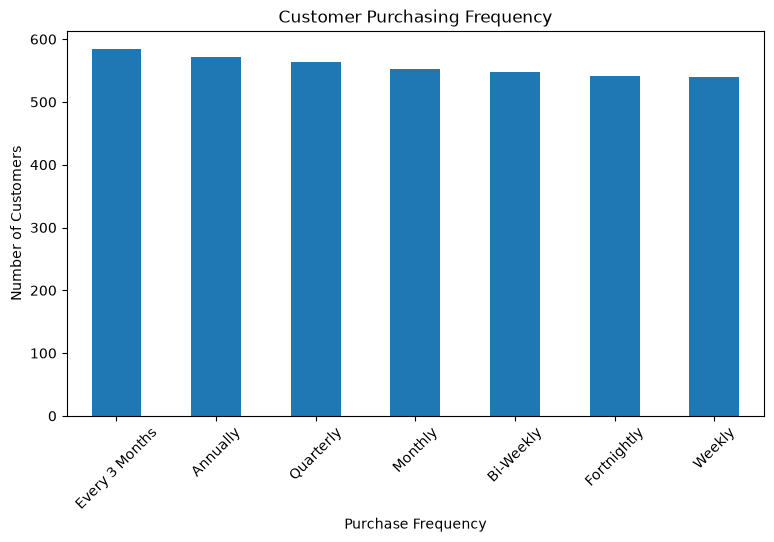

In [26]:
frequency_counts = (
    df['frequency_of_purchases']
    .value_counts()
)

plt.figure(figsize=(9, 5))
frequency_counts.plot(kind='bar')
plt.title('Customer Purchasing Frequency')
plt.xlabel('Purchase Frequency')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

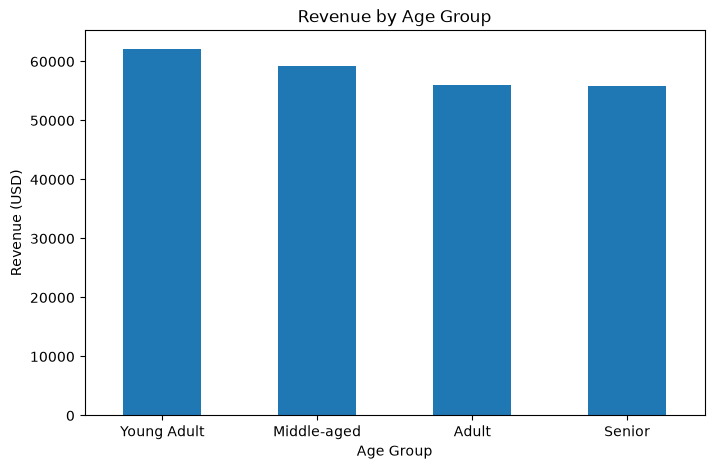

In [27]:
age_group_revenue = (
    df.groupby('age_group', observed=False)['purchase_amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
age_group_revenue.plot(kind='bar')
plt.title('Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=0)
plt.show()

## 6.7 Numerical Feature Relationships

A correlation matrix is used to examine relationships between selected numerical variables.

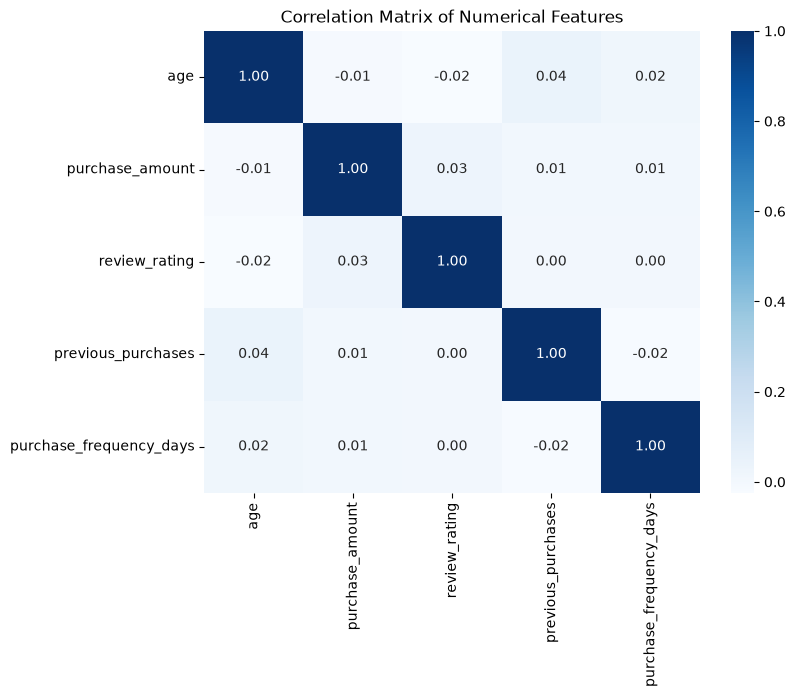

In [28]:
numeric_columns = [
    'age',
    'purchase_amount',
    'review_rating',
    'previous_purchases',
    'purchase_frequency_days'
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    fmt='.2f',
    cmap='Blues'
)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# 7. Key Findings

The exploratory analysis is used to identify patterns in customer demographics, purchasing behavior, product categories, subscription status, discounts, and purchasing frequency.

Key findings should be based on the numerical results and visualizations generated above.

These findings are further investigated through SQL queries and presented interactively through the Power BI dashboard.

# 8. PostgreSQL Integration

The cleaned and transformed dataset is loaded into PostgreSQL to support SQL-based business analysis.

This creates a workflow connecting Python-based data preparation with relational database analysis.

In [29]:
import sys
print(sys.executable)

C:\Users\kruti\anaconda3\python.exe


In [30]:
%pip install sqlalchemy psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [31]:
import sqlalchemy
import psycopg2

print("SQLAlchemy:", sqlalchemy.__version__)
print("psycopg2: installed successfully")

SQLAlchemy: 2.0.51
psycopg2: installed successfully


In [32]:
import socket

for host in ["127.0.0.1", "localhost"]:
    try:
        sock = socket.create_connection((host, 5432), timeout=5)
        print(f"✅ {host}:5432 is reachable from Jupyter")
        sock.close()
    except Exception as e:
        print(f"❌ {host}:5432 failed")
        print(e)

✅ 127.0.0.1:5432 is reachable from Jupyter
✅ localhost:5432 is reachable from Jupyter


In [33]:
from sqlalchemy import create_engine, text
from getpass import getpass

username = input("PostgreSQL username: ")
password = getpass("PostgreSQL password: ")

host = "127.0.0.1"
port = "5432"
database = input("PostgreSQL database name: ")

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

PostgreSQL username:  postgres
PostgreSQL password:  ········
PostgreSQL database name:  customer_behavior


In [34]:
try:
    with engine.connect() as connection:
        result = connection.execute(text("SELECT version();"))
        print(result.scalar())

    print("\n✅ PostgreSQL connection successful.")

except Exception as e:
    print("❌ PostgreSQL connection failed.")
    print("Error:", e)

PostgreSQL 18.6 on x86_64-windows, compiled by msvc-19.44.35228, 64-bit

✅ PostgreSQL connection successful.


In [35]:
import pandas as pd
query = """
SELECT datname
FROM pg_database
WHERE datistemplate = false
ORDER BY datname;
"""

with engine.connect() as connection:
    databases = pd.read_sql(text(query), connection)

databases

,datname
0,customer_behavior
1,postgres


In [36]:
df.to_sql(
    "customer",
    engine,
    if_exists="replace",
    index=False
)

print("✅ Cleaned dataset uploaded successfully.")

✅ Cleaned dataset uploaded successfully.


# 9. Conclusion

This analysis demonstrates an end-to-end customer analytics workflow using Python, PostgreSQL, SQL, and Power BI.

The project covers:

- Data loading and inspection
- Data quality assessment
- Missing-value handling
- Feature engineering
- Exploratory data analysis
- Customer behavior analysis
- PostgreSQL integration
- Business intelligence dashboarding

The processed dataset is used for SQL-based analysis, while the Power BI dashboard provides an interactive interface for exploring customer behavior and business patterns.